# Importing the required libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import r2_score, explained_variance_score, mean_absolute_error

C:\Users\Ajay\anaconda3\lib\site-packages\scipy\__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.2)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


In [2]:
import seaborn as sb
%matplotlib inline

# Importing the data

In [3]:
db=pd.read_csv('Groundwater.csv')

In [4]:
db.head()

,States,Recharge from rainfallMonsoon season,Recharge from other sources,Recharge from rainfallNon-monsoon season,Recharge from other sources.1,Total_Rainfall,Natural discharge during non-monsoon season,Net annual groundwater availability,Irrigation,Domestic and industrial uses,Total_Usage,Projected demand for domestic and industrial uses upto 2025,Groundwater availability for future irrigation use,Situation
0,Andhra Pradesh,15.1,6.5000,5.5,6.7000,33.8,3.1,30.8,12.600,1.500,14.200,2.70,15.9,EXCESS
1,Arunachal Pradesh,3.4,0.0003,1.0,0.0004,4.5,0.5,4.0,0.002,0.001,0.003,0.01,4.0,SEMICRITICAL
2,Assam,19.0,2.2000,8.6,0.6000,30.4,2.5,27.8,5.300,0.700,6.000,1.00,21.5,EXCESS
3,Bihar,18.9,3.9000,3.4,2.4000,28.6,2.4,26.2,9.800,1.600,11.400,2.60,13.9,MODERATED
4,Chhattisgarh,9.9,0.6000,0.9,0.9000,12.2,0.6,11.6,3.100,0.500,3.600,0.60,7.9,MODERATED


<AxesSubplot:xlabel='Situation', ylabel='count'>

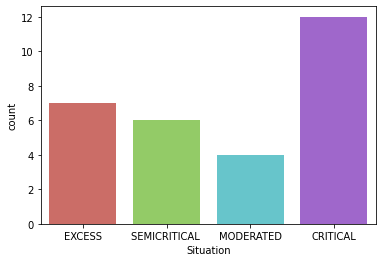

In [5]:
sb.countplot(x='Situation',data=db, palette='hls')

In [6]:
Availabilty = pd.get_dummies(db['Situation'],drop_first=True)
Availabilty.head()
val=pd.factorize(db['Situation'])[0]
val

array([0, 1, 0, 2, 2, 3, 3, 2, 3, 3, 1, 1, 2, 1, 0, 0, 3, 3, 3, 3, 0, 3,
       3, 3, 1, 1, 0, 3, 0], dtype=int64)

In [7]:
db.drop(['Situation'],axis=1,inplace=True)
db.head()
db['Situation']=val


In [8]:
new_data = pd.concat([db,Availabilty],axis=1)
new_data.head()

,States,Recharge from rainfallMonsoon season,Recharge from other sources,Recharge from rainfallNon-monsoon season,Recharge from other sources.1,Total_Rainfall,Natural discharge during non-monsoon season,Net annual groundwater availability,Irrigation,Domestic and industrial uses,Total_Usage,Projected demand for domestic and industrial uses upto 2025,Groundwater availability for future irrigation use,Situation,EXCESS,MODERATED,SEMICRITICAL
0,Andhra Pradesh,15.1,6.5000,5.5,6.7000,33.8,3.1,30.8,12.600,1.500,14.200,2.70,15.9,0,1,0,0
1,Arunachal Pradesh,3.4,0.0003,1.0,0.0004,4.5,0.5,4.0,0.002,0.001,0.003,0.01,4.0,1,0,0,1
2,Assam,19.0,2.2000,8.6,0.6000,30.4,2.5,27.8,5.300,0.700,6.000,1.00,21.5,0,1,0,0
3,Bihar,18.9,3.9000,3.4,2.4000,28.6,2.4,26.2,9.800,1.600,11.400,2.60,13.9,2,0,1,0
4,Chhattisgarh,9.9,0.6000,0.9,0.9000,12.2,0.6,11.6,3.100,0.500,3.600,0.60,7.9,2,0,1,0


In [9]:
X=new_data.iloc[:,[5,6,7,10,11,12]].values
Y=new_data.iloc[:, 14].values

# Preprocessing of data

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.55, random_state = 0)

In [11]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [12]:
new_data.describe()

,Recharge from rainfallMonsoon season,Recharge from other sources,Recharge from rainfallNon-monsoon season,Recharge from other sources.1,Total_Rainfall,Natural discharge during non-monsoon season,Net annual groundwater availability,Irrigation,Domestic and industrial uses,Total_Usage,Projected demand for domestic and industrial uses upto 2025,Groundwater availability for future irrigation use,Situation,EXCESS,MODERATED,SEMICRITICAL
count,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000
mean,8.490690,2.328976,1.563793,2.474152,14.846207,1.210483,13.644483,7.631724,0.758021,8.392048,1.063483,5.292414,1.724138,0.241379,0.137931,0.206897
std,9.909697,3.420270,2.139700,3.733489,16.931169,1.448532,15.538660,10.802838,0.798408,11.440317,1.172055,7.782267,1.250616,0.435494,0.350931,0.412251
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.040000,0.000000,0.000200,0.000400,0.001000,-14.600000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.010000,0.200000,0.100000,1.200000,0.100000,1.100000,0.100000,0.030000,0.200000,0.100000,0.400000,1.000000,0.000000,0.000000,0.000000
50%,4.800000,0.700000,0.800000,0.900000,10.500000,0.600000,9.800000,3.100000,0.700000,3.600000,0.800000,3.000000,2.000000,0.000000,0.000000,0.000000
75%,12.200000,2.700000,1.900000,3.500000,22.900000,2.000000,20.700000,11.900000,1.100000,13.000000,1.700000,11.900000,3.000000,0.000000,0.000000,0.000000
max,40.800000,11.400000,8.600000,17.700000,75.300000,6.700000,68.600000,46.000000,3.500000,49.500000,5.400000,21.500000,3.000000,1.000000,1.000000,1.000000


# GRAPH,PIE CHARTS PLOT

<AxesSubplot:xlabel='EXCESS', ylabel='count'>

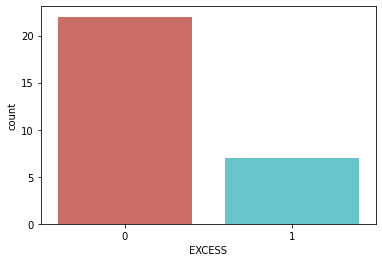

In [13]:
sb.countplot(x='EXCESS',data=new_data, palette='hls')

<AxesSubplot:xlabel='MODERATED', ylabel='count'>

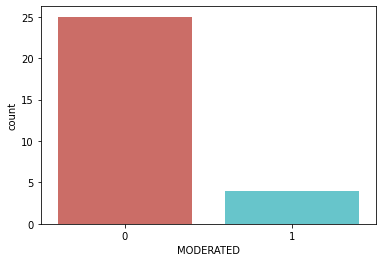

In [14]:
sb.countplot(x='MODERATED',data=new_data, palette='hls')

# Feature Correlation Graphs  Heat Map

<AxesSubplot:>

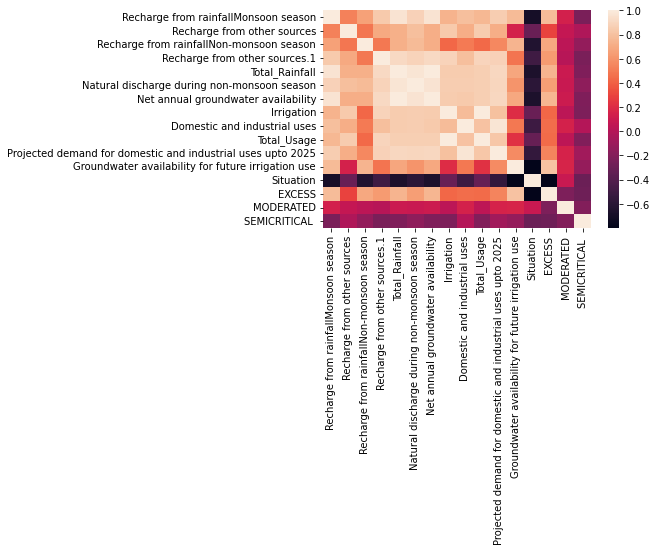

In [15]:
sb.heatmap(new_data.corr())

## PIECHART REPRESENTATION FOR NET ANNUM GROUND WATER

In [16]:
labels='Total Rainfall','Net Annual GroundWater','Total Use','Future Available','Projected demand for domestic and industrial uses upto 2025','Natural discharge during non-monsoon season'
sizes=[14.84,13.64,8.39,5.29,1.063483,1.210483]
cols = ['c','m','r','b','g','y']

([<matplotlib.patches.Wedge at 0x1f9c95b06d0>,
 [Text(-0.9537411719150084, 0.5480673106418469, 'Total Rainfall'),
  Text(-0.08733339820968328, -1.1065590257899254, 'Net Annual GroundWater'),
  Text(1.1053078027537007, -0.10195421115278551, 'Total Use'),
  Text(0.7113105849433492, 0.8521368738339814, 'Future Available'),
  Text(0.2926496966968201, 1.1637680847244691, 'Projected demand for domestic and industrial uses upto 2025'),
  Text(0.11112363521941154, 1.2952418838563027, 'Natural discharge during non-monsoon season')],
 [Text(-0.5202224574081863, 0.29894580580464375, '33.4%'),
  Text(-0.04799402964676288, -0.6081090141728419, '30.7%'),
  Text(0.6074214051168985, -0.05602889081369293, '18.9%'),
  Text(0.39090041154544414, 0.4682914351700257, '11.9%'),
  Text(0.17071232307314507, 0.6788647160892737, '2.4%'),
  Text(0.06838377551963787, 0.7970719285269554, '2.7%')])

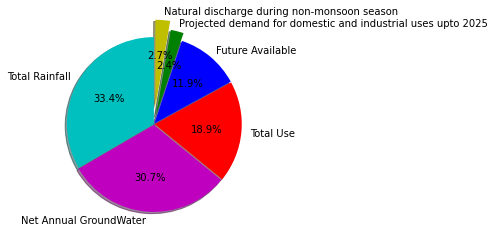

In [17]:
plt.pie(sizes,labels=labels,colors=cols,startangle=90,shadow=True,explode=(0,0.01,0.01,0.01,0.1,0.2),autopct='%1.1f%%')

## PIECHART REPRESENT THE SITUATION IN % 

In [18]:
label='EXCESS','MODERATED','SEMI-CRITICAL','CRITICAL'
sizes=[7,4,6,6]
cols = ['c','m','r','b']

([<matplotlib.patches.Wedge at 0x1f9c9725ca0>,
 [Text(-0.9150062538795929, 0.6458819980160727, 'EXCESS'),
  Text(-0.700507679540436, -0.8610394827793171, 'MODERATED'),
  Text(0.7005075586159268, -0.8610395811587026, 'SEMI-CRITICAL'),
  Text(0.8185363453415478, 0.76445945043207, 'CRITICAL')],
 [Text(-0.5065213191119174, 0.3575418203303259, '30.4%'),
  Text(-0.3849636797474468, -0.4731838599057508, '17.4%'),
  Text(0.3849636132934372, -0.4731839139700978, '26.1%'),
  Text(0.4531183340283569, 0.4231829100606101, '26.1%')])

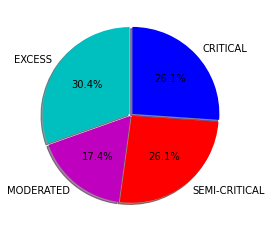

In [19]:
plt.pie(sizes,labels=label,colors=cols,startangle=90,shadow=True,explode=(0.02,0.01,0.01,0.02),autopct='%1.1f%%')

## DISTPLOT IN BTW TOTAL_RAINFALL,NET GROUNDWATER,RECHARGE IN MANSOON SEASON

C:\Users\Ajay\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\Ajay\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\Ajay\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level 

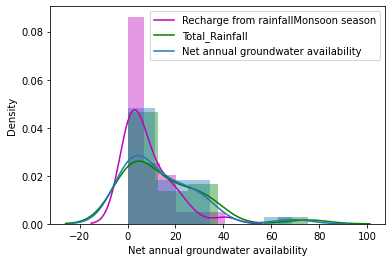

In [20]:
sb.distplot(new_data['Recharge from rainfallMonsoon season'],color='m')
sb.distplot(new_data['Total_Rainfall'],color='g')
sb.distplot(new_data['Net annual groundwater availability'])
plt.legend(['Recharge from rainfallMonsoon season','Total_Rainfall','Net annual groundwater availability'])

C:\Users\Ajay\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\Ajay\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


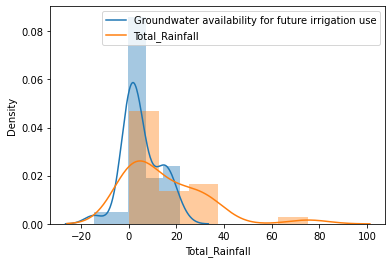

In [21]:
sb.distplot(new_data['Groundwater availability for future irrigation use'])
sb.distplot(new_data['Total_Rainfall'])
plt.legend(['Groundwater availability for future irrigation use','Total_Rainfall'])

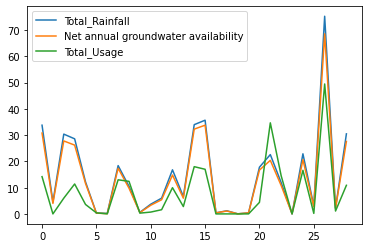

In [22]:
new_data["Total_Rainfall"].plot(kind='line')
new_data["Net annual groundwater availability"].plot()
new_data["Total_Usage"].plot()
plt.legend(['Total_Rainfall','Net annual groundwater availability','Total_Usage'])

# PREDICTING THROUGH DECISION TREE CLASSIFIER

In [23]:
from sklearn.tree import DecisionTreeClassifier

In [24]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size = .55, random_state=0)

In [25]:
tree = DecisionTreeClassifier()
tree.fit(X_train, Y_train)
X_test

array([[ 3.04e+01,  2.50e+00,  2.78e+01,  6.00e+00,  1.00e+00,  2.15e+01],
       [ 1.78e+01,  1.10e+00,  1.67e+01,  4.40e+00,  1.30e+00,  1.19e+01],
       [ 0.00e+00,  0.00e+00,  5.00e-02,  1.00e-02,  1.00e-02,  3.00e-02],
       [ 6.60e+00,  6.00e-01,  6.00e+00,  2.80e+00,  1.70e+00,  3.00e+00],
       [ 6.00e+00,  6.00e-01,  5.40e+00,  1.60e+00,  6.00e-01,  3.60e+00],
       [ 3.00e+00,  2.00e-01,  2.70e+00,  2.00e-01,  2.00e-01,  2.40e+00],
       [ 2.20e+00,  1.00e-01,  2.10e+00,  1.10e+00,  1.00e-01,  1.00e+00],
       [ 7.53e+01,  6.70e+00,  6.86e+01,  4.95e+01,  5.40e+00,  1.72e+01],
       [ 3.00e-01,  2.00e-02,  3.00e-01,  4.00e-01,  3.00e-01,  1.00e-02],
       [ 3.40e+01,  1.70e+00,  3.23e+01,  1.80e+01,  1.80e+00,  1.38e+01],
       [ 1.05e+01,  7.00e-01,  9.80e+00,  1.24e+01,  8.00e-01, -2.70e+00],
       [ 4.00e-01,  4.00e-02,  4.00e-01,  4.00e-03,  1.00e-01,  4.00e-01],
       [ 1.19e+01,  1.10e+00,  1.08e+01,  1.45e+01,  1.80e+00,  8.00e-01],
       [ 1.20e+00,  1.00e

In [26]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
X_scaled=ss.fit_transform(X)

In [27]:
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled,Y,test_size = 0.33)

In [28]:
tree = DecisionTreeClassifier()
tree.fit(X_train, Y_train)
X_test

array([[ 9.34909026e-01,  9.05981129e-01,  9.27111915e-01,
        -2.12790313e-01, -5.51223807e-02,  2.11949409e+00],
       [ 4.66065808e-01,  6.95208966e-01,  4.42450842e-01,
         2.34028608e+00, -5.51223807e-02, -2.60136537e+00],
       [-8.68334118e-01, -8.22350611e-01, -8.67443949e-01,
        -7.46178678e-01, -8.36596653e-01, -6.39789416e-01],
       [-1.77090913e-01, -7.76223002e-02, -1.86298658e-01,
         5.43347295e-01,  6.39521417e-01, -5.87480724e-01],
       [-8.68334118e-01, -8.22350611e-01, -8.67443949e-01,
        -7.45644934e-01, -9.14744080e-01, -6.39789416e-01],
       [-8.20247634e-01, -7.80196178e-01, -8.21597631e-01,
        -7.46356593e-01, -8.36596653e-01, -5.61326378e-01],
       [ 1.13927658e+00,  1.32752546e+00,  1.12359613e+00,
         5.16660085e-01,  1.42099569e+00,  1.38717240e+00],
       [ 2.13611768e-01, -7.76223002e-02,  2.45966624e-01,
         4.09911247e-01,  3.79029993e-01,  9.92061400e-04],
       [-7.60139529e-01, -7.80196178e-01, -7.561

In [29]:
tree.feature_importances_

array([0.90952381, 0.        , 0.09047619, 0.        , 0.        ,
       0.        ])

In [30]:
print("accuracy on training set: %f" % tree.score(X_train, Y_train))
print("accuracy on test set: %f" % tree.score(X_test, Y_test))

accuracy on training set: 1.000000
accuracy on test set: 0.700000


In [31]:
tree.feature_importances_

array([0.90952381, 0.        , 0.09047619, 0.        , 0.        ,
       0.        ])

In [32]:
features_names = new_data.columns
features_names

Index(['States', 'Recharge from rainfallMonsoon season',
       'Recharge from other sources',
       'Recharge from rainfallNon-monsoon season',
       'Recharge from other sources.1', 'Total_Rainfall',
       'Natural discharge during non-monsoon season',
       'Net annual groundwater availability', 'Irrigation',
       'Domestic and industrial uses', 'Total_Usage',
       'Projected demand for domestic and industrial uses upto 2025',
       'Groundwater availability for future irrigation use', 'Situation',
       'EXCESS', 'MODERATED', 'SEMICRITICAL '],
      dtype='object')

In [33]:
predictions1 = tree.predict(X_test)
print(f'R^2 score: {r2_score(y_true=Y_test, y_pred=predictions1):.2f}')
print(f'MAE score: {mean_absolute_error(y_true=Y_test, y_pred=predictions1):.2f}')

R^2 score: -0.87
MAE score: 0.30


In [34]:
tree.score(X_test,Y_test)

0.7

# PREDICTING THROUGH RANDOM FOREST

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import export_graphviz
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [36]:
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled,Y,test_size = 0.40)
X_train

array([[-0.53172873, -0.42890924, -0.53997025, -0.60420272, -0.40244428,
        -0.22131988],
       [-0.86833412, -0.82235061, -0.86744395, -0.74564493, -0.91474408,
        -0.63978942],
       [-0.26124226, -0.35865185, -0.2517934 ,  0.35653683, -0.22878333,
        -1.04518178],
       [-0.89237736, -0.85045357, -0.89036711, -0.74564493, -0.91474408,
        -0.68817496],
       [-0.88997304, -0.84764327, -0.89102206, -0.74649892, -0.92255882,
        -0.68686724],
       [-0.17709091, -0.0776223 , -0.18629866,  0.5433473 ,  0.63952142,
        -0.58748072],
       [-0.88035574, -0.78019618, -0.88709237, -0.74297621, -0.88869494,
        -0.67902093],
       [ 0.94091984,  1.18701068,  0.91401297,  0.22310078, -0.05512238,
         1.50486696],
       [-0.71205305, -0.70993879, -0.71680605, -0.72874303, -0.74976618,
        -0.37824596],
       [-0.15905848, -0.42890924, -0.13390287, -0.42628799, -0.40244428,
         0.34099856],
       [-0.82024763, -0.78019618, -0.82159763, -0.

In [37]:
model=RandomForestClassifier()
model.fit(X_train,Y_train)


RandomForestClassifier()

In [38]:
model.score(X_test,Y_test)

0.8333333333333334

In [39]:
X=new_data.iloc[:,[5,6,7,10,11,12]].values
y=new_data.iloc[:, 14].values

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.55, random_state=0)

In [41]:
random = RandomForestClassifier()
random.fit(X_train, y_train)

RandomForestClassifier()

In [42]:
print("accuracy on training set: %f" % random.score(X_train, y_train))
print("accuracy on test set: %f" % random.score(X_test, y_test))

accuracy on training set: 1.000000
accuracy on test set: 0.937500


In [43]:
predictions = random.predict(X_test)
print(f'R^2 score: {r2_score(y_true=y_test, y_pred=predictions):.2f}')
print(f'MAE score: {mean_absolute_error(y_true=y_test, y_pred=predictions):.2f}')
print(f'EVS score: {explained_variance_score(y_true=y_test, y_pred=predictions):.2f}')

R^2 score: 0.67
MAE score: 15.94
EVS score: 0.69


In [44]:
from sklearn.pipeline import make_pipeline

In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
clf = make_pipeline(StandardScaler(), SVC(gamma='auto'))

In [46]:
clf.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(gamma='auto'))])

In [47]:
print("Accuracy on training set:%f"%clf.score(X_train,y_train))
print("Accuracy on testing set:%f"%clf.score(X_test,y_test))

Accuracy on training set:1.000000
Accuracy on testing set:0.875000


In [48]:
predictions2 = clf.predict(X_test)
print(f'R^2 score: {r2_score(y_true=y_test, y_pred=predictions2):.2f}')
print(f'MAE score: {mean_absolute_error(y_true=y_test, y_pred=predictions2):.2f}')
print(f'EVS score: {explained_variance_score(y_true=y_test, y_pred=predictions2):.2f}')

R^2 score: 0.33
MAE score: 31.88
EVS score: 0.42


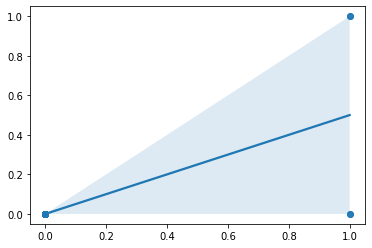

In [49]:
rp = sb.regplot(x=y_test, y=predictions2)

In [50]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size = 0.40)

In [51]:
clf = make_pipeline(SVC(gamma='auto'))
clf.fit(X_train, Y_train)

Pipeline(steps=[('svc', SVC(gamma='auto'))])

In [52]:
clf.score(X_test,Y_test)

0.6666666666666666

In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import export_graphviz
import matplotlib.pyplot as plt
X=new_data.iloc[:,[5,6,7,10,11,12]]
Y=new_data.iloc[:,[13]]
X_tr, X_te, y_tr, y_te = train_test_split(X, Y, test_size=0.55, random_state=0)

In [54]:
random=RandomForestClassifier()
random.fit(X_tr,y_tr)
random.predict(X_te)

<ipython-input-54-e4681913862a>:2: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  random.fit(X_tr,y_tr)


array([0, 2, 3, 2, 3, 3, 3, 0, 3, 0, 3, 3, 2, 3, 3, 3], dtype=int64)

In [55]:
random.predict_proba(X_tr)

array([[0.71, 0.01, 0.21, 0.07],
       [0.  , 0.  , 0.01, 0.99],
       [0.01, 0.  , 0.79, 0.2 ],
       [0.  , 0.  , 0.01, 0.99],
       [0.  , 0.  , 0.01, 0.99],
       [0.  , 0.  , 0.01, 0.99],
       [0.03, 0.06, 0.87, 0.04],
       [0.06, 0.63, 0.28, 0.03],
       [0.27, 0.05, 0.68, 0.  ],
       [0.92, 0.03, 0.05, 0.  ],
       [0.  , 0.15, 0.06, 0.79],
       [0.87, 0.07, 0.05, 0.01],
       [0.03, 0.01, 0.93, 0.03]])

In [56]:
random.predict_proba(X_te)

array([[0.67, 0.03, 0.22, 0.08],
       [0.05, 0.  , 0.91, 0.04],
       [0.  , 0.  , 0.01, 0.99],
       [0.02, 0.13, 0.5 , 0.35],
       [0.01, 0.02, 0.4 , 0.57],
       [0.  , 0.  , 0.02, 0.98],
       [0.  , 0.  , 0.01, 0.99],
       [0.9 , 0.05, 0.03, 0.02],
       [0.  , 0.  , 0.01, 0.99],
       [0.68, 0.12, 0.19, 0.01],
       [0.  , 0.05, 0.35, 0.6 ],
       [0.  , 0.  , 0.01, 0.99],
       [0.04, 0.16, 0.4 , 0.4 ],
       [0.  , 0.  , 0.01, 0.99],
       [0.01, 0.02, 0.37, 0.6 ],
       [0.  , 0.01, 0.13, 0.86]])

In [57]:
target={'0':'EXCESS','1':'SEMICRITICAL','2':'MODERATED','3':'CRITICAL'}
pr=random.predict(X_te)
pr=list(pr)
st=[]
for i in pr:
    st.append(target[str(i)])
st

['EXCESS',
 'MODERATED',
 'CRITICAL',
 'MODERATED',
 'CRITICAL',
 'CRITICAL',
 'CRITICAL',
 'EXCESS',
 'CRITICAL',
 'EXCESS',
 'CRITICAL',
 'CRITICAL',
 'MODERATED',
 'CRITICAL',
 'CRITICAL',
 'CRITICAL']

In [58]:
db


,States,Recharge from rainfallMonsoon season,Recharge from other sources,Recharge from rainfallNon-monsoon season,Recharge from other sources.1,Total_Rainfall,Natural discharge during non-monsoon season,Net annual groundwater availability,Irrigation,Domestic and industrial uses,Total_Usage,Projected demand for domestic and industrial uses upto 2025,Groundwater availability for future irrigation use,Situation
0,Andhra Pradesh,15.10,6.5000,5.50,6.7000,33.80,3.100,30.80,12.600,1.5000,14.2000,2.700,15.90,0
1,Arunachal Pradesh,3.40,0.0003,1.00,0.0004,4.50,0.500,4.00,0.002,0.0010,0.0030,0.010,4.00,1
2,Assam,19.00,2.2000,8.60,0.6000,30.40,2.500,27.80,5.300,0.7000,6.0000,1.000,21.50,0
3,Bihar,18.90,3.9000,3.40,2.4000,28.60,2.400,26.20,9.800,1.6000,11.4000,2.600,13.90,2
4,Chhattisgarh,9.90,0.6000,0.90,0.9000,12.20,0.600,11.60,3.100,0.5000,3.6000,0.600,7.90,2
5,Delhi,0.10,0.1000,0.02,0.1000,0.30,0.020,0.30,0.100,0.3000,0.4000,0.300,0.01,3
6,Goa,0.10,0.0100,0.01,0.1000,0.20,0.100,0.10,0.010,0.0300,0.0400,0.040,0.10,3
7,Gujarat,12.20,2.8000,0.00,3.5000,18.40,1.100,17.40,11.900,1.1000,13.0000,1.500,5.30,2
8,Haryana,3.50,2.7000,1.00,3.3000,10.50,0.700,9.80,11.700,0.7000,12.4000,0.800,-2.70,3
9,Himachal Pradesh,0.40,0.0200,0.10,0.0400,0.60,0.100,0.50,0.200,0.1000,0.3000,0.100,0.20,3


In [73]:
db['States'][1:10]

1    Arunachal Pradesh
2                Assam
3                Bihar
4         Chhattisgarh
5                Delhi
6                  Goa
7              Gujarat
8              Haryana
9     Himachal Pradesh
Name: States, dtype: object

In [97]:
for i in len(['States'])
    print(db['States'][0])

SyntaxError: invalid syntax (<ipython-input-97-fc0c53b00e71>, line 1)